In [1]:
import sys
sys.path.insert(0, "pipeline")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from preprocessing import load_and_preprocess
from benchmark import run_benchmark, print_summary, run_stat_models, run_ml_models

FILE_PATH = r'C:\Users\kaila\Documents\TCC\data\cientista_cp.xlsx'
TEST_YEAR = 2025

In [3]:
data = load_and_preprocess(FILE_PATH)

df_full        = data["df_full"]
df_ml          = data["df_ml"]
df_by_programa = data["df_by_programa"]
encoders       = data["encoders"]
programas      = data["programas"]
anos           = data["anos"]

print(f"df_full : {df_full.shape}")
print(f"df_ml   : {df_ml.shape}")
print(f"Programas: {programas}")
print(f"Anos    : {anos}")
df_ml.head(1)

[preproc] Dados carregados: 517 linhas, 10 colunas
[preproc] Anos disponíveis: [2021, 2022, 2023, 2024, 2025]
[preproc] Programas: ['PESCA ARTESANAL', 'ZONA CANAVIEIRA', 'FRUTICULTURA IRRIGADA']
[preproc] Municípios únicos: 101
[preproc] Grid expandido: 691 linhas (adicionadas 174 combinações sem dados)
df_full : (691, 14)
df_ml   : (691, 18)
Programas: ['FRUTICULTURA IRRIGADA', 'PESCA ARTESANAL', 'ZONA CANAVIEIRA']
Anos    : [2021, 2022, 2023, 2024, 2025]


,MUNICIPIO,PROGRAMA,ANO,cadastros,beneficiarios,valor,total_pcp,total_pcp_corrigido,valor_total,cd_mun,DATE,MUNICIPIO_CODE,PROGRAMA_CODE,ano_rel,lag_1,lag_2,rolling_mean_2,trend
0,ABREU E LIMA,PESCA ARTESANAL,2021,78.0,77.0,14790.0,59160.0,59160.0,59160.0,2600054.0,2021-01-01,0,1,0,0.0,0.0,0.0,0.0


In [3]:
df_results = run_benchmark(FILE_PATH, test_year=TEST_YEAR)

[preproc] Dados carregados: 517 linhas, 10 colunas
[preproc] Anos disponíveis: [2021, 2022, 2023, 2024, 2025]
[preproc] Programas: ['PESCA ARTESANAL', 'ZONA CANAVIEIRA', 'FRUTICULTURA IRRIGADA']
[preproc] Municípios únicos: 101
[preproc] Grid expandido: 691 linhas (adicionadas 174 combinações sem dados)

[benchmark] Ano de teste: 2025
[benchmark] Programas   : ['FRUTICULTURA IRRIGADA', 'PESCA ARTESANAL', 'ZONA CANAVIEIRA']
[benchmark] Anos treino : [2021, 2022, 2023, 2024]

MODO GLOBAL (todos os dados)
  ARIMA                MAE=    814.95  RMSE=    814.95  MAPE%=  4.06
  ETS                  MAE=   7269.49  RMSE=   7269.49  MAPE%= 36.22
  LinearRegression     MAE=   5388.03  RMSE=   6084.69  MAPE%= 79.02
  DecisionTree         MAE=    1871.3  RMSE=   2270.41  MAPE%= 34.58
  RandomForest         MAE=    772.77  RMSE=    852.09  MAPE%= 11.98
  LightGBM             MAE=    382.55  RMSE=    469.31  MAPE%=  7.67

MODO POR SETOR

  >> FRUTICULTURA IRRIGADA
     ARIMA                MAE=    

#### Quanto esse modelo erra na previsão do total de beneficiários por setor?

In [4]:
print_summary(df_results)
df_results


RESUMO FINAL
    familia           modelo      modo              programa      MAE     RMSE  MAPE%
Estatístico              ETS POR_SETOR       ZONA CANAVIEIRA   376.00   376.00   3.78
Estatístico            ARIMA    GLOBAL                 TODOS   814.95   814.95   4.06
Estatístico            ARIMA POR_SETOR FRUTICULTURA IRRIGADA   181.19   181.19   4.31
Estatístico            ARIMA POR_SETOR       ZONA CANAVIEIRA   872.65   872.65   8.78
Estatístico              ETS POR_SETOR       PESCA ARTESANAL   541.51   541.51   9.14
Estatístico            ARIMA POR_SETOR       PESCA ARTESANAL   551.83   551.83   9.32
Estatístico              ETS POR_SETOR FRUTICULTURA IRRIGADA   865.00   865.00  20.58
Estatístico              ETS    GLOBAL                 TODOS  7269.49  7269.49  36.22
ML Clássico     DecisionTree POR_SETOR       PESCA ARTESANAL     1.96     1.96   0.03
ML Clássico LinearRegression POR_SETOR FRUTICULTURA IRRIGADA   394.58   394.58   9.39
ML Clássico     DecisionTree POR_SETOR F

,modelo,familia,modo,MAE,RMSE,MAPE%,y_true,y_pred,scope,programa,y_true_total,y_pred_total
0,ARIMA,Estatístico,GLOBAL,814.95,814.95,4.06,20070.0,20884.950809,GLOBAL,TODOS,NaN,NaN
1,ETS,Estatístico,GLOBAL,7269.49,7269.49,36.22,20070.0,12800.511892,GLOBAL,TODOS,NaN,NaN
2,LinearRegression,ML Clássico,GLOBAL,5388.03,6084.69,79.02,NaN,NaN,GLOBAL,TODOS,20070.0,3906.0
3,DecisionTree,ML Clássico,GLOBAL,1871.30,2270.41,34.58,NaN,NaN,GLOBAL,TODOS,20070.0,21135.0
4,RandomForest,ML Moderno,GLOBAL,772.77,852.09,11.98,NaN,NaN,GLOBAL,TODOS,20070.0,19244.0
5,LightGBM,ML Moderno,GLOBAL,382.55,469.31,7.67,NaN,NaN,GLOBAL,TODOS,20070.0,19984.0
6,ARIMA,Estatístico,POR_SETOR,181.19,181.19,4.31,4203.0,4384.194611,POR_SETOR,FRUTICULTURA IRRIGADA,NaN,NaN
7,ETS,Estatístico,POR_SETOR,865.00,865.00,20.58,4203.0,5067.999972,POR_SETOR,FRUTICULTURA IRRIGADA,NaN,NaN
8,LinearRegression,ML Clássico,POR_SETOR,394.58,394.58,9.39,NaN,NaN,POR_SETOR,FRUTICULTURA IRRIGADA,4203.0,3808.0
9,DecisionTree,ML Clássico,POR_SETOR,938.88,938.88,22.34,NaN,NaN,POR_SETOR,FRUTICULTURA IRRIGADA,4203.0,5142.0


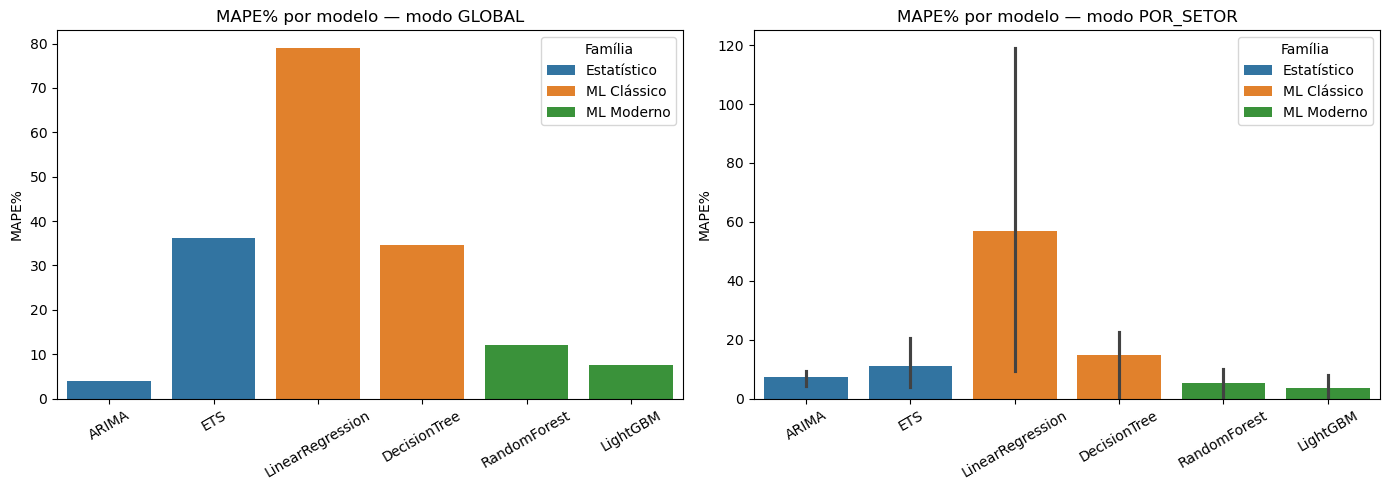

In [5]:
df_plot = df_results.dropna(subset=["MAPE%"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, modo in zip(axes, ["GLOBAL", "POR_SETOR"]):
    sub = df_plot[df_plot["modo"] == modo]
    sns.barplot(data=sub, x="modelo", y="MAPE%", hue="familia", ax=ax)
    ax.set_title(f"MAPE% por modelo — modo {modo}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Família")

plt.tight_layout()
plt.show()

In [6]:
for prog in programas:
    sub = df_results[
        (df_results["modo"] == "POR_SETOR") &
        (df_results["programa"] == prog)
    ].dropna(subset=["MAPE%"]).sort_values("MAPE%")
    
    print(f"\n{'='*50}")
    print(f"Setor: {prog}")
    print(sub[["familia", "modelo", "MAE", "RMSE", "MAPE%"]].to_string(index=False))


Setor: FRUTICULTURA IRRIGADA
    familia           modelo    MAE   RMSE  MAPE%
 ML Moderno     RandomForest   9.80   9.80   0.23
 ML Moderno         LightGBM 100.98 100.98   2.40
Estatístico            ARIMA 181.19 181.19   4.31
ML Clássico LinearRegression 394.58 394.58   9.39
Estatístico              ETS 865.00 865.00  20.58
ML Clássico     DecisionTree 938.88 938.88  22.34

Setor: PESCA ARTESANAL
    familia           modelo     MAE    RMSE  MAPE%
ML Clássico     DecisionTree    1.96    1.96   0.03
 ML Moderno     RandomForest  335.17  335.17   5.66
 ML Moderno         LightGBM  482.29  482.29   8.14
Estatístico              ETS  541.51  541.51   9.14
Estatístico            ARIMA  551.83  551.83   9.32
ML Clássico LinearRegression 2526.83 2526.83  42.66

Setor: ZONA CANAVIEIRA
    familia           modelo      MAE     RMSE  MAPE%
 ML Moderno         LightGBM    64.88    64.88   0.65
Estatístico              ETS   376.00   376.00   3.78
Estatístico            ARIMA   872.65   872.65

In [7]:
df_results.to_csv("resultados_benchmark.csv", index=False)
print("Salvo em resultados_benchmark.csv")

Salvo em resultados_benchmark.csv


In [8]:
from sklearn.tree import DecisionTreeRegressor
from preprocessing import TARGET, YEAR_COL

ML_FEATURES = ["ANO", "MUNICIPIO_CODE", "PROGRAMA_CODE",
                "lag_1", "lag_2", "rolling_mean_2", "trend", "ano_rel"]

feats = [f for f in ML_FEATURES if f in df_ml.columns]

pesca = df_ml[df_ml["PROGRAMA"] == "PESCA ARTESANAL"].copy()
train = pesca[pesca[YEAR_COL] < 2025]
test  = pesca[pesca[YEAR_COL] == 2025]
test  = test[~((test["lag_1"] == 0) & (test[TARGET] == 0))]

X_train, y_train = train[feats], train[TARGET]
X_test,  y_test  = test[feats],  test[TARGET]

dt = DecisionTreeRegressor(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
preds = dt.predict(X_test)

# 1. Comparação real vs previsto por município
diagnostico = test[["MUNICIPIO", TARGET]].copy()
diagnostico["previsto"]   = preds
diagnostico["erro_abs"]   = (diagnostico[TARGET] - diagnostico["previsto"]).abs()
diagnostico["lag_1"]      = test["lag_1"].values
print("Real vs Previsto (Pesca 2025):")
print(diagnostico.sort_values("erro_abs", ascending=False).to_string(index=False))

# 2. Será que previsto == lag_1? (sinal clássico de leakage)
iguais = (diagnostico["previsto"] == diagnostico["lag_1"]).sum()
print(f"\nLinhas onde previsto == lag_1: {iguais} de {len(diagnostico)}")

# 3. Feature importance
import pandas as pd
fi = pd.Series(dt.feature_importances_, index=feats).sort_values(ascending=False)
print("\nFeature importances:")
print(fi)

Real vs Previsto (Pesca 2025):
               MUNICIPIO  beneficiarios    previsto  erro_abs  lag_1
                 IPOJUCA          186.0   89.307692 96.692308   98.0
 CABO DE SANTO AGOSTINHO          162.0   89.307692 72.692308  120.0
                IGARASSU          511.0  443.250000 67.750000  477.0
              ITAPISSUMA          183.0  248.750000 65.750000  220.0
SAO JOSE DA COROA GRANDE          398.0  443.250000 45.250000  373.0
       ILHA DE ITAMARACA          409.0  443.250000 34.250000  372.0
               SIRINHAEM          416.0  443.250000 27.250000  383.0
                  OLINDA          114.0   89.307692 24.692308  112.0
                LIMOEIRO           34.0    9.550000 24.450000   23.0
        LAGOA DO ITAENGA           30.0    9.550000 20.450000   17.0
          LAGOA DO CARRO           29.0    9.550000 19.450000   14.0
               TAMANDARE          243.0  224.250000 18.750000  235.0
               GAMELEIRA           25.0    9.550000 15.450000   21.0
   